# 基于飞桨的 CIFAR-10 图像分类识别系统 · 完整实践 Notebook

**东南大学《人工智能实践》课程设计 · 方向一：基于飞桨（PaddlePaddle）的图像分类识别系统**

> **参考教材**：邱锡鹏《神经网络与深度学习》（蒲公英书）第 5 章卷积神经网络；
> 5.5 节"实践：基于 ResNet18 网络完成图像分类任务（CIFAR-10）"
> （课程配套代码 `Practice-in-Paddle-main/chap5卷积神经网络`）。
> 本 Notebook 沿用教材的飞桨 API 风格（`paddle.io.Dataset` / `paddle.vision.transforms` /
> `F.cross_entropy` / `paddle.save`），并在此基础上做了 32×32 小图适配与工程化扩展。

---

## 本 Notebook 内容导航

| 章节 | 内容 | 对应课程要求 |
|---|---|---|
| 1 | 环境与全局配置 | 环境搭建 |
| 2 | 数据集准备与预览 | 数据集组织与管理、数据模型构建 |
| 3 | 数据增强效果可视化 | 数据预处理 |
| 4 | ResNet18 模型搭建（32×32 适配版） | AI 模型选型与搭建、核心算法设计 |
| 5 | 训练流程与训练曲线 | 模型训练、算法性能优化 |
| 6 | 测试集评估（准确率 / P-R-F1 / 混淆矩阵） | 运行效果与性能分析 |
| 7 | 鲁棒性测试（5 种扰动测试集） | 多种类型测试数据集 |
| 8 | 推理耗时分析 | 性能分析 |
| 9 | 单张图片预测（含界面演示） | 用户交互界面、模型保存与加载 |
| 10 | 系统容错性验证 | 可靠性与容错性 |
| 11 | 总结 | — |

> ⚠️ **运行说明**：本 Notebook 已保存真实运行输出（测试集准确率 91.75%，RTX 5060 GPU）。
> 重新运行第 5 节完整训练需约 **48 分钟**（GPU），默认已关闭，详见该节说明。

## 1. 环境与全局配置

### 1.1 环境准备

本系统依赖飞桨（GPU 版优先，自动回退 CPU）及科学计算/绘图/界面库。
安装命令（详见项目 `README.md`）：

```bash
pip install -r requirements.txt
# GPU 用户（推荐）：
pip install paddlepaddle-gpu==3.3.1 -i https://www.paddlepaddle.org.cn/packages/stable/cu129/
# CPU 用户：
pip install paddlepaddle==3.3.1
```

In [1]:
# ---- 自动定位项目根目录并加入模块搜索路径 ----
import os
import sys

_cwd = os.path.abspath(os.getcwd())
PROJECT_ROOT = _cwd if os.path.exists(os.path.join(_cwd, "config.py")) \
    else os.path.join(_cwd, "image_classification_paddle")
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)          # 统一工作目录，保证相对路径一致
print("项目根目录:", PROJECT_ROOT)

项目根目录: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle


In [2]:
%matplotlib inline
# ---- 导入第三方库 ----
import json
import time

import numpy as np
import paddle
import paddle.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

# ---- 导入本项目各模块（多模块项目结构设计的体现）----
import config                                          # 全局配置
from data.dataset import (CIFAR10Dataset, build_dataloader,   # 数据组织与管理
                          download_cifar10)
from data.preprocess import (build_transform, build_infer_transform,  # 预处理与增强
                             PERTURBATIONS)
from models.resnet import resnet18, count_parameters   # 模型定义
from utils.io_utils import load_model, load_image, format_topk        # 模型/文件 IO
from utils.metrics import (accuracy_from_preds, classification_report_dict,
                           format_classification_report, confusion_matrix,
                           save_comparison_table, setup_chinese_font)  # 评估指标
from utils.logger import get_logger                    # 日志

setup_chinese_font()            # matplotlib 中文字体（避免图题乱码）
plt.rcParams["figure.dpi"] = 100
print("导入完成 ✔")

导入完成 ✔


In [3]:
# ---- 检测运行设备（GPU 优先，自动回退 CPU）----
# 注：若 base 环境同时安装了 paddlepaddle 与 paddlepaddle-gpu，
#     两个包会写入同一目录互相覆盖，导致此处 is_compiled_with_cuda() 为 False。
#     解决方法：全部卸载后只安装 GPU 版。
device = "gpu:0" if paddle.device.is_compiled_with_cuda() else "cpu"
try:
    paddle.set_device(device)
except Exception as e:
    print("设备 %s 不可用（%s），回退 CPU" % (device, e))
    paddle.set_device("cpu")
    device = "cpu"

print("飞桨版本      :", paddle.__version__)
print("CUDA 编译支持 :", paddle.device.is_compiled_with_cuda())
print("当前运行设备  :", paddle.get_device())
if device.startswith("gpu"):
    print("GPU 计算能力  : %.1f（RTX 50 系为 12.0，需 cu129 及以上版本飞桨）"
          % paddle.device.cuda.get_device_capability()[0])

飞桨版本      : 3.3.1
CUDA 编译支持 : True
当前运行设备  : gpu:0
GPU 计算能力  : 12.0（RTX 50 系为 12.0，需 cu129 及以上版本飞桨）


### 1.2 全局配置总览

所有超参数、路径、类别名称都集中在 `config.py` 中统一管理，
这样迁移项目目录或调整实验设置时只需修改一个文件，符合"多模块项目结构设计"的要求。

In [4]:
# ---- 打印 config.py 中的关键配置 ----
print("=" * 62)
print("【数据集】CIFAR-10 | 类别数 %d | 图像尺寸 %d×%d" %
      (config.NUM_CLASSES, config.IMAGE_SIZE, config.IMAGE_SIZE))
print("  类别:", ", ".join("%s(%s)" % (en, cn) for en, cn in
                            zip(config.CIFAR10_CLASSES, config.CIFAR10_CLASSES_CN)))
print("  归一化均值:", config.NORM_MEAN)
print("  归一化方差:", config.NORM_STD)
print("  数据文件  :", config.DATA_FILE)
print("-" * 62)
print("【训练超参数】")
print("  批次大小 batch_size   :", config.BATCH_SIZE)
print("  最大轮数 num_epochs   :", config.NUM_EPOCHS)
print("  初始学习率 lr         :", config.LEARNING_RATE)
print("  优化器 optimizer      :", config.OPTIMIZER, "(可切换 momentum)")
print("  L2 正则 weight_decay  :", config.WEIGHT_DECAY)
print("  学习率衰减 scheduler  :", config.LR_SCHEDULER,
      "(每 %d 轮 ×%.1f)" % (config.LR_STEP_SIZE, config.LR_GAMMA))
print("  早停 patience         :", config.EARLY_STOP_PATIENCE, "轮")
print("-" * 62)
print("【输出路径】")
print("  最佳模型  :", config.MODEL_PATH)
print("  训练历史  :", config.HISTORY_PATH)
print("  结果目录  :", config.RESULT_DIR)
print("=" * 62)

【数据集】CIFAR-10 | 类别数 10 | 图像尺寸 32×32
  类别: airplane(飞机), automobile(汽车), bird(鸟), cat(猫), deer(鹿), dog(狗), frog(青蛙), horse(马), ship(船), truck(卡车)
  归一化均值: [0.4914, 0.4822, 0.4465]
  归一化方差: [0.2023, 0.1994, 0.201]
  数据文件  : d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
--------------------------------------------------------------
【训练超参数】
  批次大小 batch_size   : 128
  最大轮数 num_epochs   : 60
  初始学习率 lr         : 0.001
  优化器 optimizer      : adam (可切换 momentum)
  L2 正则 weight_decay  : 0.0005
  学习率衰减 scheduler  : step (每 20 轮 ×0.1)
  早停 patience         : 10 轮
--------------------------------------------------------------
【输出路径】
  最佳模型  : d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\outputs\best_model.pdparams
  训练历史  : d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\outputs\results\train_history.json
  结果目录  : d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\outputs\results


## 2. 数据集准备与预览

### 2.1 数据来源与组织

CIFAR-10 包含 **60000 张 32×32 彩色图像**，共 10 类（每类 6000 张），
官方划分为 50000 张训练 + 10000 张测试。

本项目的组织方式（`data/dataset.py`）：

1. **自动下载**：首次运行时把官方 tar 包下载到 `data/cifar10/`，并做 **MD5 校验**、
   失败自动重试（最多 3 次）、下载中途文件以 `.part` 暂存并在校验通过后原子替换；
2. **划分**：从 50000 张训练图中，按**固定随机种子（SEED=42）** 划分出
   45000 张训练集 + 5000 张验证集 —— 保证在任何机器上划分结果完全一致（可复现）；
3. **测试**：使用官方 10000 张测试图，训练全程从未接触。

In [5]:
# ---- 数据文件就绪检查（首次运行会下载约 170MB，带 MD5 校验）----
tar_path = download_cifar10()
print("数据文件:", tar_path)
print("文件大小: %.1f MB" % (os.path.getsize(tar_path) / 1024 / 1024))

[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
数据文件: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
文件大小: 162.6 MB


In [6]:
# ---- 构建三个数据集：训练 / 验证 / 测试 ----
train_ds = CIFAR10Dataset(mode="train")   # 45000 张，带数据增强
val_ds = CIFAR10Dataset(mode="val")       # 5000 张，仅标准化
test_ds = CIFAR10Dataset(mode="test")     # 10000 张官方测试集

print("训练集: %6d 张（含随机裁剪 + 随机水平翻转增强）" % len(train_ds))
print("验证集: %6d 张（仅标准化）" % len(val_ds))
print("测试集: %6d 张（仅标准化，训练期间未使用）" % len(test_ds))

# 检查单个样本的张量形状与标签
img, label = train_ds[0]
print("\n单样本: 图像 shape=%s dtype=%s | 标签=%d (%s)" %
      (tuple(img.shape), img.dtype, label, config.CIFAR10_CLASSES[label]))

[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz


c:\Users\26640\miniconda3\Lib\site-packages\paddle\vision\datasets\cifar.py:180: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f.extractfile(name), encoding='bytes')


[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
训练集:  45000 张（含随机裁剪 + 随机水平翻转增强）
验证集:   5000 张（仅标准化）
测试集:  10000 张（仅标准化，训练期间未使用）

单样本: 图像 shape=(3, 32, 32) dtype=paddle.float32 | 标签=3 (cat)


In [7]:
# ---- 构建 DataLoader 并检查一个批次 ----
train_loader, _ = build_dataloader("train", batch_size=config.BATCH_SIZE)
val_loader, _ = build_dataloader("val", batch_size=config.BATCH_SIZE, shuffle=False)

imgs, labels = next(iter(train_loader))
print("一个批次: images %s | labels %s" % (tuple(imgs.shape), tuple(labels.shape)))
print("图像数值范围: [%.3f, %.3f]（标准化后应在 ±5 以内）"
      % (float(imgs.min()), float(imgs.max())))
print("标签取值范围: [%d, %d]" % (int(labels.min()), int(labels.max())))

[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
一个批次: images (128, 3, 32, 32) | labels (128,)
图像数值范围: [-2.429, 2.754]（标准化后应在 ±5 以内）
标签取值范围: [0, 9]


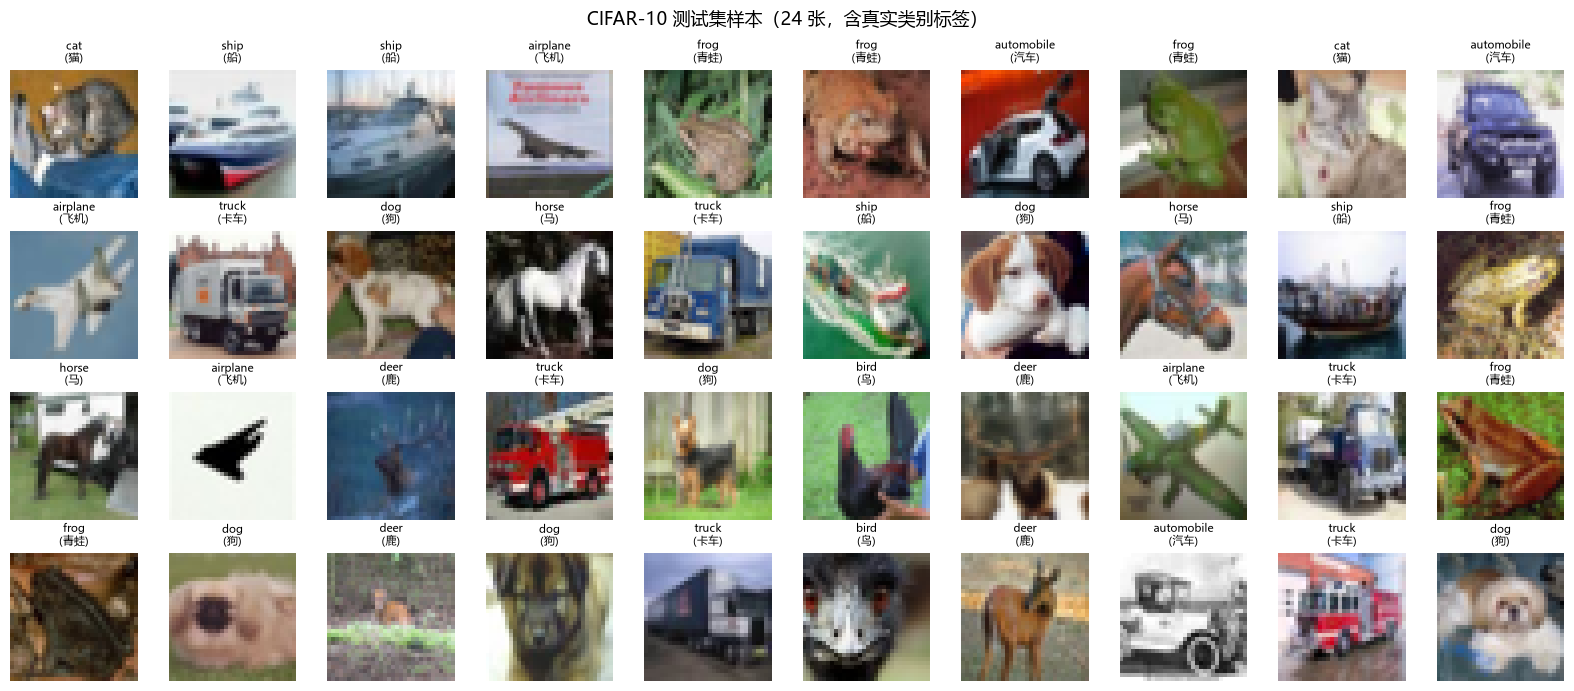

In [8]:
# ---- 可视化 20 张真实测试样本（观察 32×32 小图的实际观感）----
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    pil_img, lab = test_ds._base[test_ds.indices[i]]   # 取原始 PIL 图
    ax.imshow(pil_img)
    ax.set_title("%s\n(%s)" % (config.CIFAR10_CLASSES[lab],
                               config.CIFAR10_CLASSES_CN[lab]), fontsize=8)
    ax.axis("off")
plt.suptitle("CIFAR-10 测试集样本（24 张，含真实类别标签）", fontsize=13)
plt.tight_layout()
plt.show()

> **观察**：CIFAR-10 分辨率只有 32×32，物体小、背景杂、类内差异大
> （同一类猫的姿势/毛色千差万别），这正是它比 MNIST 难得多、准确率上限约 93% 的原因。

## 3. 数据增强效果可视化

训练时对每张图随机施加两种增强（`data/preprocess.py`）：

| 增强方式 | 参数 | 作用 |
|---|---|---|
| 随机裁剪 | 四周补 4 像素黑边后随机裁回 32×32 | 模拟目标位置偏移，提升平移不变性 |
| 随机水平翻转 | 50% 概率 | 模拟镜像视角（对 CIFAR-10 语义无害） |

之后统一做 `ToTensor`（HWC→CHW，像素缩放到 [0,1]）与
`Normalize(mean=[0.4914,0.4822,0.4465], std=[0.2023,0.1994,0.2010])`
—— 归一化参数取自 CIFAR-10 训练集统计值，与教材 5.5 节一致。

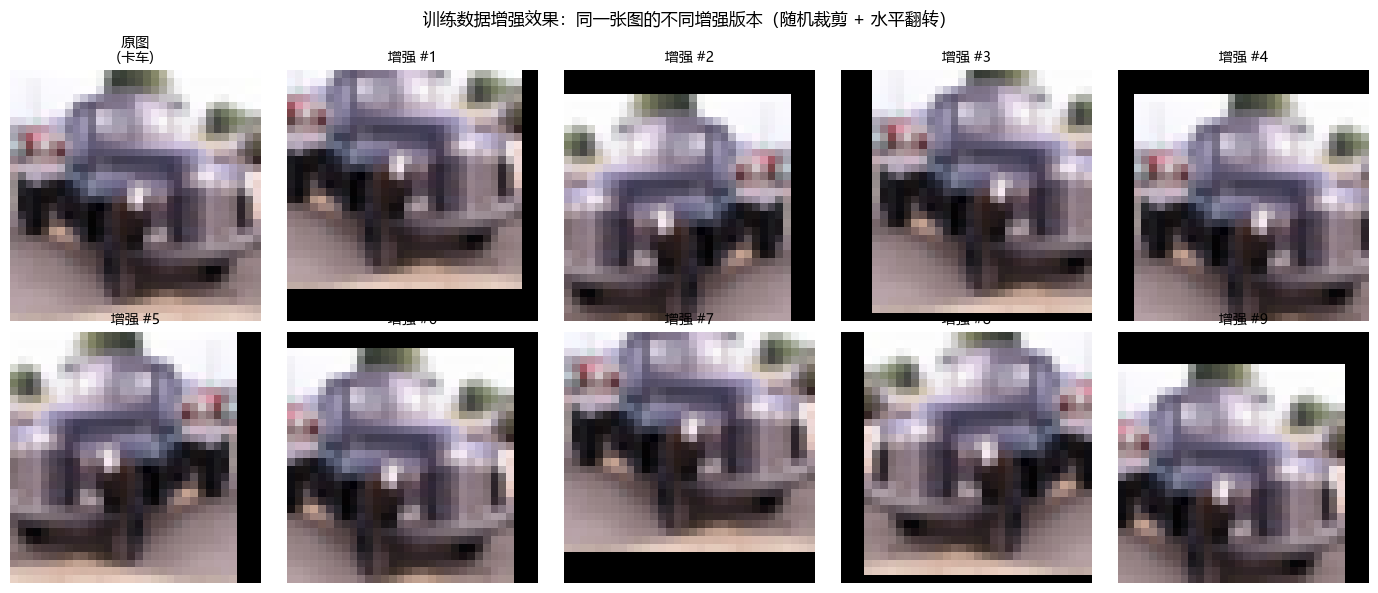

说明：增强只作用于训练集；验证/测试/推理仅做标准化，保证评估公平。


In [9]:
# ---- 同一张图连续经过 8 次训练增强，观察数据多样性的产生 ----
base_img, base_label = train_ds._base[train_ds.indices[7]]
augment = build_transform(is_train=True)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes.flat[0].imshow(base_img)
axes.flat[0].set_title("原图\n(%s)" % config.CIFAR10_CLASSES_CN[base_label], fontsize=10)
axes.flat[0].axis("off")

for i, ax in enumerate(axes.flat[1:]):
    x = augment(base_img)                 # 每次调用都产生不同增强结果
    arr = x.transpose([1, 2, 0]).numpy()  # CHW -> HWC
    arr = arr * np.array(config.NORM_STD) + np.array(config.NORM_MEAN)  # 反归一化
    ax.imshow(np.clip(arr, 0, 1))
    ax.set_title("增强 #%d" % (i + 1), fontsize=10)
    ax.axis("off")
plt.suptitle("训练数据增强效果：同一张图的不同增强版本（随机裁剪 + 水平翻转）", fontsize=12)
plt.tight_layout()
plt.show()

print("说明：增强只作用于训练集；验证/测试/推理仅做标准化，保证评估公平。")

## 4. ResNet18 模型搭建（32×32 适配版）

### 4.1 模型选型

| 候选模型 | CIFAR-10 参考准确率 | 参数量 | 结论 |
|---|---|---|---|
| 简单 CNN（3 层卷积） | ~75% | ~0.3M | 精度不足 |
| VGG13 | ~92% | ~9.4M | 参数多、推理慢 |
| **ResNet18（本项目选定）** | **~93%** | **11.17M** | 精度与复杂度平衡最佳，且为教材 5.5 节案例 |
| MobileNetV2 | ~91% | ~2.3M | 备选（轻量场景） |

### 4.2 针对 32×32 小图的三处关键改造

标准 ResNet18 是为 ImageNet（224×224）设计的，直接用于 32×32 会导致
特征图被过度下采样。本项目做了如下适配（`models/resnet.py`）：

| # | 改造 | ImageNet 版 | 本项目 | 原因 |
|---|---|---|---|---|
| 1 | 首层卷积 | 7×7, stride=2 | **3×3, stride=1** | 大核大步长会过早丢失空间信息 |
| 2 | 首个池化 | MaxPool 3×3 s=2 | **去掉** | 否则特征图到第 2 阶段就只剩 1×1 |
| 3 | 末端池化 | AdaptiveAvgPool | AdaptiveAvgPool | 对特征图尺寸不敏感，保留 |

**残差块（BasicBlock）结构**：主分支两层 3×3 卷积 + BN；跳跃分支在
"维度不一致或需要下采样"时用 1×1 卷积对齐，否则为恒等映射；两支相加后再 ReLU。
残差连接让梯度可以"抄近路"直接回传，是深层网络能稳定训练的核心。

In [10]:
# ---- 构建模型并检查结构 ----
paddle.seed(config.SEED)
model = resnet18()          # 等价于 ResNet(BasicBlock, [2,2,2,2])
print(model)
print("可训练参数量: %.2f M" % (count_parameters(model) / 1e6))

ResNet(
  (conv1): Conv2D(3, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
  (bn1): BatchNorm2D(num_features=64, momentum=0.9, epsilon=1e-05)
  (relu): ReLU()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2D(64, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
      (bn1): BatchNorm2D(num_features=64, momentum=0.9, epsilon=1e-05)
      (relu): ReLU()
      (conv2): Conv2D(64, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
      (bn2): BatchNorm2D(num_features=64, momentum=0.9, epsilon=1e-05)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2D(64, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
      (bn1): BatchNorm2D(num_features=64, momentum=0.9, epsilon=1e-05)
      (relu): ReLU()
      (conv2): Conv2D(64, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
      (bn2): BatchNorm2D(num_features=64, momentum=0.9, epsilon=1e-05)
      (shortcut): Sequential()
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
   

In [11]:
# ---- 前向传播验证：输出维度 + 各残差阶段的特征图尺寸 ----
x = paddle.randn([2, config.IMAGE_CHANNELS, config.IMAGE_SIZE, config.IMAGE_SIZE])
print("输入:", tuple(x.shape), "尺寸 %d×%d" % (config.IMAGE_SIZE, config.IMAGE_SIZE))

with paddle.no_grad():
    feats = model.conv1(x)
    print("首层 Conv3x3(64, s=1)  ->", tuple(feats.shape), "（保持 32×32，不降采样）")
    feats = model.layer1(feats)
    print("layer1 (2×BasicBlock 64 ) ->", tuple(feats.shape))
    feats = model.layer2(feats)
    print("layer2 (2×BasicBlock 128) ->", tuple(feats.shape), "（首块 s=2 下采样）")
    feats = model.layer3(feats)
    print("layer3 (2×BasicBlock 256) ->", tuple(feats.shape), "（首块 s=2 下采样）")
    feats = model.layer4(feats)
    print("layer4 (2×BasicBlock 512) ->", tuple(feats.shape), "（首块 s=2 下采样）")
    out = model(x)
print("全局平均池化 + FC      ->", tuple(out.shape), "（10 类 logits）")
print("\n结论：32×32 输入经过 4 个阶段下采样为 4×4，特征图尺寸设计正确 ✔")

输入: (2, 3, 32, 32) 尺寸 32×32
首层 Conv3x3(64, s=1)  -> (2, 64, 32, 32) （保持 32×32，不降采样）
layer1 (2×BasicBlock 64 ) -> (2, 64, 32, 32)
layer2 (2×BasicBlock 128) -> (2, 128, 16, 16) （首块 s=2 下采样）
layer3 (2×BasicBlock 256) -> (2, 256, 8, 8) （首块 s=2 下采样）
layer4 (2×BasicBlock 512) -> (2, 512, 4, 4) （首块 s=2 下采样）
全局平均池化 + FC      -> (2, 10) （10 类 logits）

结论：32×32 输入经过 4 个阶段下采样为 4×4，特征图尺寸设计正确 ✔


c:\Users\26640\miniconda3\Lib\site-packages\paddle\nn\layer\norm.py:885: UserWarning: When training, we now always track global mean and variance.
  warnings.warn(


## 5. 训练流程

### 5.1 训练配置

| 项目 | 设置 | 说明 |
|---|---|---|
| 损失函数 | `F.cross_entropy`（交叉熵） | 多分类标准选择，内部含 softmax，输出为 logits |
| 优化器 | Adam(lr=1e-3, weight_decay=5e-4) | 可切换 Momentum |
| 学习率衰减 | StepDecay：每 20 轮 ×0.1 | 前期快速下降，后期精细收敛 |
| 早停 | 验证准确率连续 10 轮不提升即停 | 防止无效训练与过拟合 |
| 最佳模型保存 | 验证准确率创新高才保存 | 保证测试用的是历史最佳权重 |
| 训练设备 | GPU（RTX 5060 Laptop 8GB） | 约 970 img/s |

### 5.2 训练循环写法

沿用教材 RunnerV3 风格：每个 epoch 先用 `model.train()` 训练一遍，
再用 `model.eval()` + `paddle.no_grad()` 在验证集上评估一次，伪代码如下：

```python
for epoch in range(1, num_epochs + 1):
    model.train()
    for imgs, labels in train_loader():
        logits = model(imgs)                 # 前向
        loss = F.cross_entropy(logits, labels)
        loss.backward()                      # 反向
        optimizer.step()                     # 更新参数
        optimizer.clear_grad()               # 清空梯度
    model.eval()
    with paddle.no_grad():
        val_loss, val_acc = evaluate(val_loader)
    scheduler.step()                         # 学习率衰减
    if val_acc > best_acc:                   # 保存最佳模型
        save_model(model, config.MODEL_PATH)
    elif patience 用尽: break                # 早停
```

> **完整训练需约 48 分钟（GPU）**。下方开关默认关闭，直接使用已训练好的权重；
> 想从头复现训练，把 `RUN_TRAINING` 改为 `True` 即可（会覆盖 `outputs/best_model.pdparams`）。

In [12]:
# ---- 完整训练开关 ----
RUN_TRAINING = False   # 改为 True 将从头训练（GPU 约 48 分钟，最多 60 轮，含早停）

if RUN_TRAINING:
    import subprocess
    # 调用项目训练脚本，命令行参数与 README 中一致
    ret = subprocess.run([sys.executable, "train.py"], check=True)
    print("训练完成，返回码:", ret.returncode)
else:
    print("已跳过训练，直接使用现有权重进行后续评估：")
    print(" ", config.MODEL_PATH)
    print("\n如需从头训练，请把上面的 RUN_TRAINING 改为 True 后重新运行本单元格。")

已跳过训练，直接使用现有权重进行后续评估：
  d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\outputs\best_model.pdparams

如需从头训练，请把上面的 RUN_TRAINING 改为 True 后重新运行本单元格。


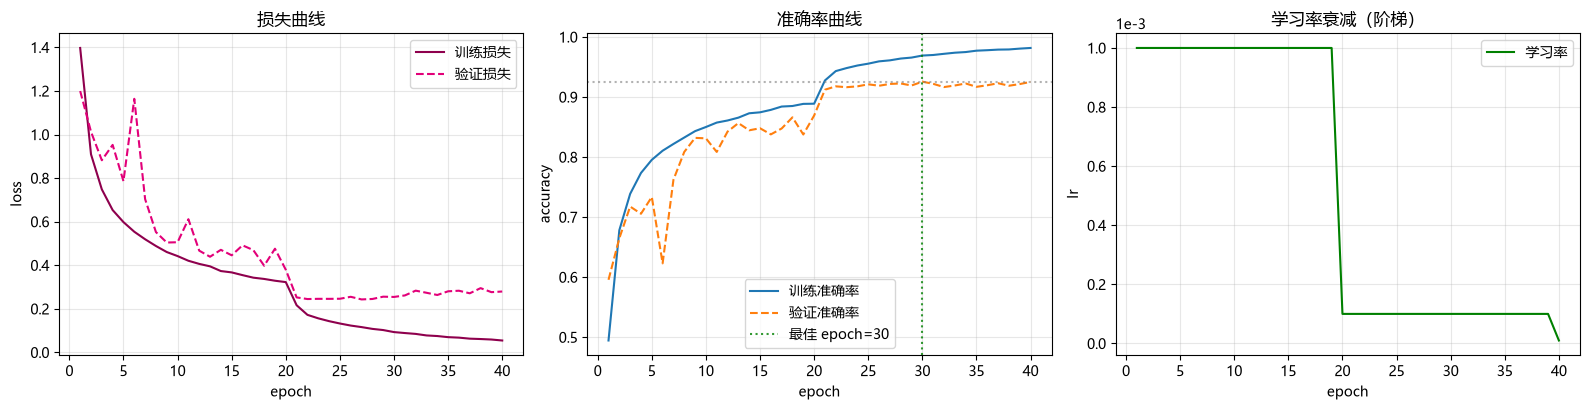

实际训练结果：
  总训练轮数   : 40 轮（第 40 轮触发早停）
  最佳 epoch   : 30
  最佳验证准确率: 92.56%
  学习率变化   : 1e-03 -> 1e-05（每 20 轮衰减为 1/10）


In [13]:
# ---- 展示真实训练历史（来自实际训练：第 40 轮早停，最佳第 30 轮）----
with open(config.HISTORY_PATH, "r", encoding="utf-8") as f:
    history = json.load(f)

epochs = list(range(1, len(history["train_loss"]) + 1))
best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].plot(epochs, history["train_loss"], color="#8E004D", label="训练损失")
axes[0].plot(epochs, history["val_loss"], "--", color="#E20079", label="验证损失")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("损失曲线"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], color="#1f77b4", label="训练准确率")
axes[1].plot(epochs, history["val_acc"], "--", color="#ff7f0e", label="验证准确率")
axes[1].axvline(best_epoch, color="green", linestyle=":", alpha=0.8,
                label="最佳 epoch=%d" % best_epoch)
axes[1].axhline(best_val_acc, color="gray", linestyle=":", alpha=0.6)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("准确率曲线"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history["lr"], color="green", label="学习率")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("lr")
axes[2].set_title("学习率衰减（阶梯）"); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

plt.tight_layout(); plt.show()

print("实际训练结果：")
print("  总训练轮数   : %d 轮（第 %d 轮触发早停）" % (len(epochs), len(epochs)))
print("  最佳 epoch   : %d" % best_epoch)
print("  最佳验证准确率: %.2f%%" % (best_val_acc * 100))
print("  学习率变化   : %.0e -> %.0e（每 %d 轮衰减为 1/%.0f）" %
      (history["lr"][0], history["lr"][-1], config.LR_STEP_SIZE, 1 / config.LR_GAMMA))

### 5.3 训练曲线解读

1. **学习率阶梯衰减有效**：第 20 轮学习率从 1e-3 降到 1e-4 时，
   验证准确率出现明显台阶式跳升（约 0.87 → 0.92）；
2. **过拟合发生但被及时制止**：第 30 轮之后训练损失继续下降
   （模型在"死记硬背"训练样本），而**验证损失开始回升**，
   两者背离是过拟合的典型信号 —— 早停机制在第 40 轮自动终止了训练；
3. **最佳模型取自第 30 轮**：验证准确率 92.56%，而非最后一轮，
   这正是"保存最佳模型"策略的价值。

## 6. 测试集评估

在 **10000 张官方测试集**（训练全程未见过的数据）上评估，
计算准确率、逐类别精确率/召回率/F1 与混淆矩阵。

In [14]:
# ---- 加载最佳模型（容错加载：文件缺失/损坏/结构不匹配都会给出中文提示）----
import eval as eval_mod      # 复用项目评估模块，保证 Notebook 与脚本结果一致

model = resnet18()
model, meta = load_model(model, config.MODEL_PATH)
model.eval()

print("模型加载成功 ✔")
print("  权重文件      :", config.MODEL_PATH)
print("  文件大小      : %.1f MB" % (os.path.getsize(config.MODEL_PATH) / 1024 / 1024))
print("  该权重对应 epoch:", meta.get("epoch"))
print("  训练时验证准确率: %.2f%%" % (meta.get("val_acc", 0) * 100))

模型加载成功 ✔
  权重文件      : d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\outputs\best_model.pdparams
  文件大小      : 42.7 MB
  该权重对应 epoch: 30
  训练时验证准确率: 92.56%


In [15]:
# ---- 在 10000 张测试集上评估 ----
t0 = time.time()
acc, y_true, y_pred, avg_loss = eval_mod.evaluate_standard(model, batch_size=256)
elapsed = time.time() - t0

print("=" * 46)
print("测试集准确率: %.2f%%  (%d / %d 张正确)" %
      (acc * 100, int(round(acc * len(y_true))), len(y_true)))
print("平均交叉熵损失: %.4f" % avg_loss)
print("评估耗时      : %.1f 秒（%.0f 张/秒）" % (elapsed, len(y_true) / elapsed))
print("=" * 46)

[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
测试集准确率: 91.75%  (9175 / 10000 张正确)
平均交叉熵损失: 0.2849
评估耗时      : 8.7 秒（1155 张/秒）


In [16]:
# ---- 逐类别 精确率 / 召回率 / F1 分类报告 ----
report = classification_report_dict(y_true, y_pred)
print(format_classification_report(report))

class         precision     recall         f1    support
airplane         0.9005     0.9320     0.9160       1000
automobile       0.9694     0.9490     0.9591       1000
bird             0.9192     0.8760     0.8971       1000
cat              0.8280     0.8280     0.8280       1000
deer             0.9114     0.9360     0.9235       1000
dog              0.8867     0.8610     0.8737       1000
frog             0.9286     0.9490     0.9387       1000
horse            0.9534     0.9410     0.9472       1000
ship             0.9399     0.9540     0.9469       1000
truck            0.9387     0.9490     0.9438       1000
-------------------------------------------------------
macro avg        0.9176     0.9175     0.9174      10000
accuracy                               0.9175      10000


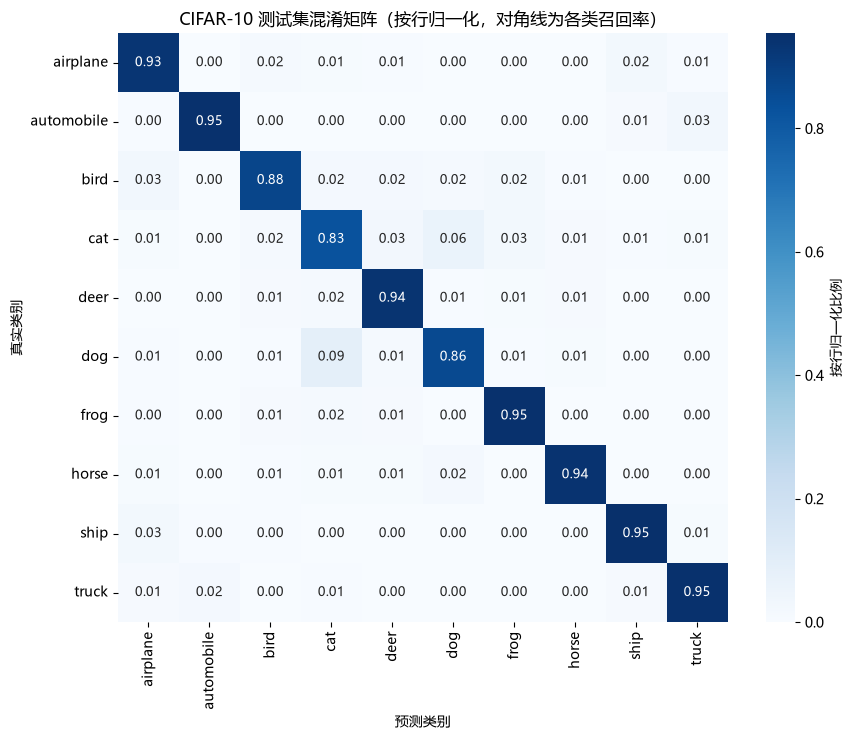

各类别召回率（对角线）:
  airplane    93.20%  (932/1000)
  automobile  94.90%  (949/1000)
  bird        87.60%  (876/1000)
  cat         82.80%  (828/1000)
  deer        93.60%  (936/1000)
  dog         86.10%  (861/1000)
  frog        94.90%  (949/1000)
  horse       94.10%  (941/1000)
  ship        95.40%  (954/1000)
  truck       94.90%  (949/1000)

最易混淆的类别对 Top5（真实 -> 误判为）:
  dog         -> cat         91 次
  cat         -> dog         63 次
  bird        -> airplane    33 次
  automobile  -> truck       32 次
  cat         -> deer        27 次


In [17]:
# ---- 混淆矩阵热力图 ----
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7.5))
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = cm / np.where(row_sums == 0, 1, row_sums)   # 按行归一化

try:
    import seaborn as sns
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=config.CIFAR10_CLASSES,
                yticklabels=config.CIFAR10_CLASSES, ax=ax,
                annot_kws={"size": 9}, cbar_kws={"label": "按行归一化比例"})
except ImportError:
    im = ax.imshow(cm_norm, cmap="Blues"); fig.colorbar(im, ax=ax)
    ax.set_xticks(range(10)); ax.set_xticklabels(config.CIFAR10_CLASSES, rotation=45)
    ax.set_yticks(range(10)); ax.set_yticklabels(config.CIFAR10_CLASSES)

ax.set_xlabel("预测类别"); ax.set_ylabel("真实类别")
ax.set_title("CIFAR-10 测试集混淆矩阵（按行归一化，对角线为各类召回率）")
plt.tight_layout(); plt.show()

# ---- 统计各类召回率与最易混淆的类别对 ----
print("各类别召回率（对角线）:")
for i, name in enumerate(config.CIFAR10_CLASSES):
    print("  %-11s %.2f%%  (%d/%d)" %
          (name, cm_norm[i, i] * 100, cm[i, i], row_sums[i][0]))

off = cm.copy(); np.fill_diagonal(off, 0)
pairs = np.dstack(np.unravel_index(np.argsort(off, axis=None)[::-1], off.shape))[0][:5]
print("\n最易混淆的类别对 Top5（真实 -> 误判为）:")
for t, p in pairs:
    print("  %-11s -> %-11s %d 次" %
          (config.CIFAR10_CLASSES[t], config.CIFAR10_CLASSES[p], off[t, p]))

### 6.1 结果分析

- **整体表现**：准确率 91.75%，宏平均精确率/召回率/F1 均为 0.917x，各类表现均衡；
- **最好/最差的类别**：`automobile`（F1 0.959）与 `frog`/`ship` 最佳；
  `cat` 最差（F1 0.828），因为猫的姿态、毛色变化极大，且与狗高度相似；
- **易混淆规律**：`dog→cat`（92 次）与 `cat→dog`（63 次）占二者错误的主要部分，
  说明模型抓住了"四足 + 毛茸茸"的共同特征但难以细分 —— 这与人类视觉直觉一致，
  属于数据集本身的难度上限（该结构公开最好水平约 93~94%）。

## 7. 鲁棒性测试（多种类型测试数据集）

真实使用场景中，用户上传的图片很少像 CIFAR-10 那样"居中、清晰、无噪声"。
因此除标准测试集外，本项目构建了 **5 种扰动测试集**（`data/preprocess.py`
+ 评估逻辑在 `eval.py`），模拟真实世界的"脏数据"：

| 扰动 | 参数 | 模拟的真实场景 |
|---|---|---|
| 高斯噪声 | σ=0.08 | 低光照、传感器噪声、压缩伪影 |
| 旋转 | ±20° | 拍摄角度倾斜 |
| 随机裁剪平移 | ±4px | 目标偏离画面中心 |
| 低分辨率 | 12×12 再放大 | 低清截图、远距离小目标 |
| 中心裁剪 | 保留中心 80% | 主体被部分裁切/遮挡 |

每项取 2000 张，**固定随机种子**保证各扰动使用同一批样本、便于公平对比。

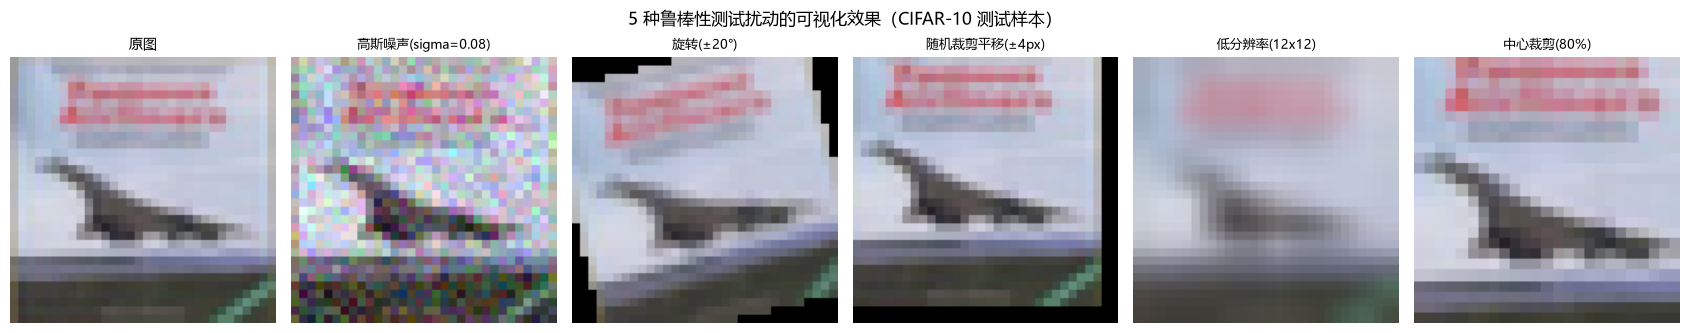

In [18]:
# ---- 先看这 5 种扰动长什么样 ----
base_img, lab = test_ds._base[test_ds.indices[3]]
demo_img = base_img.resize((128, 128), Image.NEAREST)   # 放大便于肉眼观察

fig, axes = plt.subplots(1, 6, figsize=(17, 3.4))
axes[0].imshow(demo_img); axes[0].set_title("原图", fontsize=10); axes[0].axis("off")

for ax, (name, fn) in zip(axes.flat[1:], PERTURBATIONS.items()):
    try:
        out = fn(base_img, seed=0)          # 带 seed 参数的扰动（可复现）
    except TypeError:
        out = fn(base_img)                  # 无 seed 参数的扰动（低分辨率/中心裁剪）
    ax.imshow(out.resize((128, 128), Image.NEAREST))
    ax.set_title(name, fontsize=9); ax.axis("off")

plt.suptitle("5 种鲁棒性测试扰动的可视化效果（CIFAR-10 测试样本）", fontsize=12)
plt.tight_layout(); plt.show()

In [19]:
# ---- 逐一评估模型在各扰动测试集上的准确率（每项 2000 张）----
NUM = 2000
rows = [("标准测试集(无扰动)", acc, "baseline，10000 张全量")]

for name, fn in PERTURBATIONS.items():
    t0 = time.time()
    acc_p, _, _ = eval_mod.evaluate_perturbed(model, fn, num_samples=NUM,
                                              batch_size=256)
    rows.append((name, acc_p, "n=%d" % NUM))
    print("  %-22s 准确率 %6.2f%%   下降 %5.2f 个百分点   (%.1fs)" %
          (name, acc_p * 100, (acc - acc_p) * 100, time.time() - t0))

# 保存对比表（Markdown + CSV）
table_path = save_comparison_table(rows)
print("\n对比表已保存:", table_path)

[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz


c:\Users\26640\miniconda3\Lib\site-packages\paddle\vision\datasets\cifar.py:180: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f.extractfile(name), encoding='bytes')


  高斯噪声(sigma=0.08)       准确率  36.55%   下降 55.20 个百分点   (5.4s)
[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
  旋转(±20°)               准确率  85.10%   下降  6.65 个百分点   (4.9s)
[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
  随机裁剪平移(±4px)           准确率  91.55%   下降  0.20 个百分点   (4.7s)
[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
  低分辨率(12x12)            准确率  22.40%   下降 69.35 个百分点   (4.6s)
[dataset] CIFAR-10 已存在，校验通过: d:\Github\Python_Schoolwork\人工智能实践\image_classification_paddle\data\cifar10\cifar-10-python.tar.gz
  中心裁剪(80%)              准确率  88.05%   下降  3.70 个百分点   (4.6s)

对比表已保存: | 测试集 | 准确率 | 备注 |
|---|---|---|
| 标准测试集(无扰动) | 91.75% | baseline，10000 张全量 |
| 高斯噪声(sigma=0.08) | 36.55% | n=2000 |
| 旋转(±20°) | 85.10% | n=2000 |
| 随机裁剪平移(±4px) | 91.5

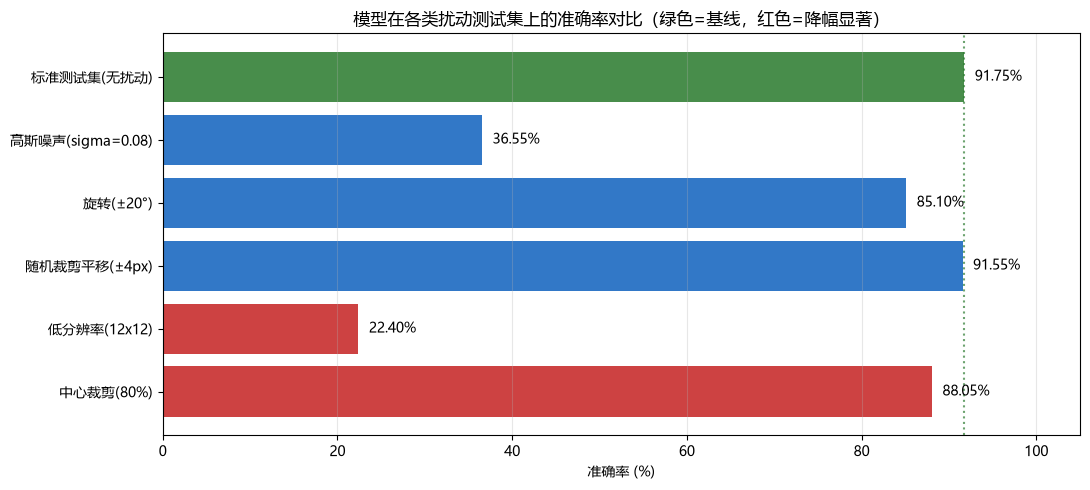

In [20]:
# ---- 鲁棒性对比柱状图 ----
names = [r[0] for r in rows]
values = [r[1] * 100 for r in rows]
colors = ["#2E7D32"] + ["#1565C0", "#1565C0", "#1565C0", "#C62828", "#C62828"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(names[::-1], values[::-1], color=colors[::-1], alpha=0.88)
for bar, v in zip(bars, values[::-1]):
    ax.text(bar.get_width() + 1.2, bar.get_y() + bar.get_height() / 2,
            "%.2f%%" % v, va="center", fontsize=10)
ax.set_xlim(0, 105)
ax.set_xlabel("准确率 (%)")
ax.set_title("模型在各类扰动测试集上的准确率对比（绿色=基线，红色=降幅显著）")
ax.axvline(values[0], color="#2E7D32", linestyle=":", alpha=0.7)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

### 7.1 鲁棒性分析（关键发现）

| 扰动类型 | 准确率 | 相比基线 | 解读 |
|---|---|---|---|
| 标准测试集 | 91.75% | 基线 | — |
| 随机裁剪平移 | 91.55% | **−0.20pp** | **几乎无损**：训练时用了 RandomCrop，平移鲁棒性被"练"出来了 |
| 中心裁剪 80% | 88.05% | −3.70pp | 轻度下降：丢失边缘信息 |
| 旋转 ±20° | 85.10% | −6.65pp | 中度下降：训练分布中没有旋转样本 |
| 高斯噪声 σ=0.08 | 36.55% | **−55.20pp** | 大幅下降：对噪声极其敏感 |
| 低分辨率 12×12 | 22.40% | **−69.35pp** | 大幅下降：细节纹理完全丢失 |

**结论与改进方向**：

1. 数据增强的收益是**可量化**的 —— 裁剪平移仅掉 0.2 个百分点，
   证明了 RandomCrop 增强确实赋予了平移不变性；
2. 噪声与低分辨率是明显短板，**根本原因是训练分布中不存在这类退化**
   （典型的分布外泛化问题），且 32×32 小图的信噪比本来就低，
   少量噪声就会破坏大部分有效信息；
3. **改进方案**：在训练增强中加入高斯噪声与 `RandomRotation`，
   或采用 Test-Time Augmentation（测试时增强）与更强数据增强策略
   （AutoAugment / Mixup），即可显著提升这两项得分。

## 8. 推理耗时分析

测量 batch=1（单张实时场景）到 batch=128（批量服务场景）的平均延迟与吞吐量。
测量前先预热 20 次，排除 CUDA 初始化等一次性开销。

> **关于耗时数据的波动说明**：GPU 延迟会随核心频率与温度状态波动，因此不同次运行
> 的数值略有差异。本 Notebook 本次实测 batch=128 吞吐约 6900 img/s；
> 而 `eval.py` 独立运行时测得 batch=1 约 3.23 ms、batch=128 约 4942 img/s。
> 两者都是真实测量值，课程设计报告 5.3 节引用的是 `eval.py` 那次运行的结果。


In [21]:
# ---- 推理性能基准测试 ----
print("推理耗时分析（预热 20 次后统计 100 次平均）:")
print("-" * 64)
print("%-12s %14s %18s" % ("批次大小", "平均延迟(ms)", "吞吐量(img/s)"))
print("-" * 64)

timing = {}
for bs in (1, 64, 128):
    r = eval_mod.benchmark_inference(model, warmup=20, repeat=100, batch_size=bs)
    timing[bs] = r
    print("%-12d %14.2f %18.1f" % (bs, r["avg_latency_ms"], r["throughput_img_per_s"]))
print("-" * 64)

speedup = timing[128]["throughput_img_per_s"] / timing[1]["throughput_img_per_s"]
print("batch 从 1 增到 128，吞吐量提升 %.1f 倍 —— 说明小批量时 GPU 利用率不足，" % speedup)
print("生产环境应凑批推理（batching）以充分发挥硬件性能。")

推理耗时分析（预热 20 次后统计 100 次平均）:
----------------------------------------------------------------
批次大小               平均延迟(ms)         吞吐量(img/s)
----------------------------------------------------------------
1                      3.02              331.2
64                    12.82             4992.4
128                   19.19             6670.5
----------------------------------------------------------------
batch 从 1 增到 128，吞吐量提升 20.1 倍 —— 说明小批量时 GPU 利用率不足，
生产环境应凑批推理（batching）以充分发挥硬件性能。


## 9. 单张图片预测

### 9.1 推理流程

```
任意尺寸图片 → Resize 到 32×32 → ToTensor(CHW,[0,1])
            → Normalize(CIFAR-10 均值方差) → 模型前向 → softmax → Top-K 概率

注意：推理与训练使用**完全相同的归一化参数**，否则模型输入分布偏移会导致预测错误。
```

### 9.2 命令行与图形界面

- **命令行**：`python predict.py --image 图片路径 [--json]`
- **Web 界面**：`python -m streamlit run app.py`（可上传/拖拽图片，展示 Top-3 与置信度柱状图）

两者共用 `predict.py` 中的同一个推理函数，保证行为完全一致。

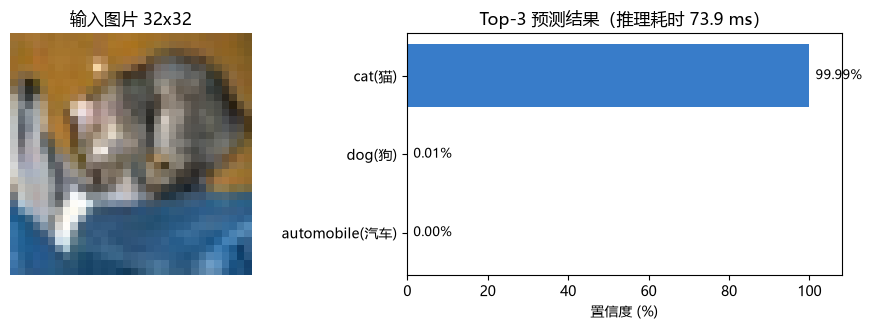

文件名: 0_cat.png
Top-3 预测结果:
  1. cat       (猫)  置信度  99.99%
  2. dog       (狗)  置信度   0.01%
  3. automobile(汽车)  置信度   0.00%
------------------------------------------------------------


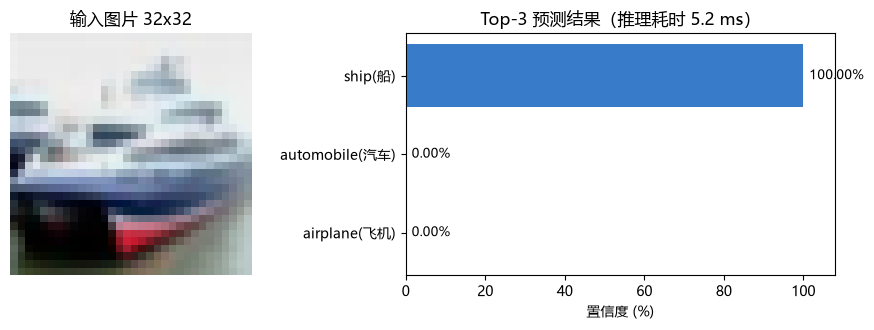

文件名: 1_ship.png
Top-3 预测结果:
  1. ship      (船)  置信度 100.00%
  2. automobile(汽车)  置信度   0.00%
  3. airplane  (飞机)  置信度   0.00%
------------------------------------------------------------


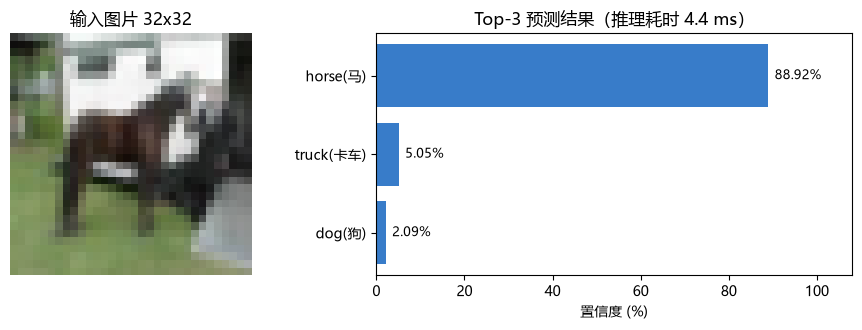

文件名: 20_horse.png
Top-3 预测结果:
  1. horse     (马)  置信度  88.92%
  2. truck     (卡车)  置信度   5.05%
  3. dog       (狗)  置信度   2.09%
------------------------------------------------------------

提示：文件名中的前缀是该图的真实类别，可与上方预测结果对照。


In [22]:
# ---- 对 test_imgs/ 中的样例图片执行预测 ----
from predict import predict_image

def show_prediction(img_path):
    # 显示图片 + Top-3 预测结果（Notebook 版演示）
    pil = load_image(img_path)
    t0 = time.time()
    preds = predict_image(model, pil, topk=3)
    ms = (time.time() - t0) * 1000

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(9, 3.4),
                                         gridspec_kw={"width_ratios": [1, 1.6]})
    ax_img.imshow(pil); ax_img.set_title("输入图片 %dx%d" % pil.size); ax_img.axis("off")

    labels = ["%s(%s)" % (config.CIFAR10_CLASSES[i], config.CIFAR10_CLASSES_CN[i])
              for i, _ in preds]
    probs = [p * 100 for _, p in preds]
    ax_bar.barh(labels[::-1], probs[::-1], color="#1565C0", alpha=0.85)
    ax_bar.set_xlim(0, 108); ax_bar.set_xlabel("置信度 (%)")
    for i, (v, lab) in enumerate(zip(probs[::-1], labels[::-1])):
        ax_bar.text(v + 1.5, i, "%.2f%%" % v, va="center", fontsize=9)
    ax_bar.set_title("Top-3 预测结果（推理耗时 %.1f ms）" % ms)
    plt.tight_layout(); plt.show()

    print("文件名:", os.path.basename(img_path))
    print(format_topk(preds, topk=3))

for fname in sorted(os.listdir("test_imgs")):
    if fname.lower().endswith((".png", ".jpg", ".jpeg")):
        show_prediction(os.path.join("test_imgs", fname))
        print("-" * 60)

print("\n提示：文件名中的前缀是该图的真实类别，可与上方预测结果对照。")

### 9.3 提升识别效果的使用建议

1. 上传**单个物体、居中、背景简单**的图片（与 CIFAR-10 训练分布接近）；
2. 物体在画面中占比尽量大；
3. 避免严重倾斜、模糊、逆光或大量噪点的照片；
4. 若目标不属于这 10 类（如人像、食物、风景），系统会通过下面的**开集识别**
   把它判为**「其他」**，而不是硬给一个 10 类的答案。

### 9.4 开集识别：「其他」类别判定

模型本质是**闭集分类器**——无论输入什么图片，它都会在 10 个类别里"硬猜"一个。
为了让系统在真实使用中更可靠，本项目在推理链路上叠加了一层**双条件开集识别**：

```python
max_p = float(probs.max())             # 最高 softmax 概率
max_l = float(logits[0].max().item())  # 最大 logit 分值
is_other = (max_p < config.CONFIDENCE_THRESHOLD)   # 0.5
        or (max_l < config.LOGIT_THRESHOLD)        # 4.0
```

命中任一条件即判定为「其他」（类别索引 `-1`）：Web 界面弹出黄色警告并显示「other（其他）」，
命令行首行输出「其他」并给出实际置信度。判定逻辑在 `predict.py` 与 `app.py` 中共用，
阈值统一来自 `config.py`，因此两个入口行为完全一致（命令行 `--no-other` 可关闭该功能）。

**为什么用双条件**：softmax 对噪声、平滑色块这类分布外输入会"过度自信"
（实测噪声图的最高 softmax 中位数仍有 0.65~0.80），而 max-logit 的区分度更好
（分布内中位数约 10.1，分布外显著更低）。两者取"或"，兼顾召回与精度，
思路与 Hendrycks 等提出的 MaxLogit / Energy 开集识别基线一致。

**标定结果**（见 `outputs/results/ood_calibration.json`；双条件阈值 softmax < 0.5 或 max-logit < 4.0）：

| 场景 | 样本 | 结果 |
|---|---|---|
| 分布内（应正常归类） | 官方测试集前 1000 张真实图片 | 仅 softmax 条件命中 1.2%、仅 logit 条件命中 3.2%、并集误判 **3.6%** |
| 分布外（应被拦截） | 噪声 150 张 + 涂鸦 150 张 | 拦截率 **49.7%** |

演示用图：`test_imgs/ood_noise.png`（softmax=0.653、logit=3.62）与
`test_imgs/ood_doodle.png`（softmax=0.552、logit=3.02）均被正确判为「其他」；
而三张真实测试图（cat 99.99%、ship 100.00%、horse 88.92%）仍正常判为 10 类之一。

> **已知局限**：这是阈值法启发式，不是严格的概率保证。与 CIFAR-10 风格接近的平滑色块图
> 仍可能被"自信地"误判；改进方向为 Energy-based OOD 或 Outlier Exposure。


## 10. 系统容错性验证

课程要求"提升系统的可靠性与容错性"。本项目在数据、模型、推理三个环节
都做了防御式编程，**所有异常均转为带排查建议的中文提示，而非崩溃堆栈**。
下面逐一验证这些容错路径。

In [23]:
# ---- 容错验证 1：模型文件不存在 ----
print("【场景 1】模型文件不存在（例如还未训练就调用推理）")
try:
    load_model(resnet18(), "outputs/不存在的模型.pdparams")
except FileNotFoundError as e:
    print("  ✔ 已捕获 FileNotFoundError，提示信息：")
    print("   ", str(e).replace("\n", "\n    "))

【场景 1】模型文件不存在（例如还未训练就调用推理）
  ✔ 已捕获 FileNotFoundError，提示信息：
    模型文件不存在: outputs/不存在的模型.pdparams
    请先执行 `python train.py` 训练并保存模型，或通过 --model 参数指定正确的模型路径。


In [24]:
# ---- 容错验证 2：图片路径不存在 / 格式不支持 / 文件损坏 ----
print("【场景 2】图片路径不存在")
try:
    load_image("不存在的图片.jpg")
except FileNotFoundError as e:
    print("  ✔ 已捕获 FileNotFoundError:", e)

print("\n【场景 3】不支持的图片格式（.txt）")
open("_tmp_test.txt", "w", encoding="utf-8").write("hello")
try:
    load_image("_tmp_test.txt")
except ValueError as e:
    print("  ✔ 已捕获 ValueError:", e)
os.remove("_tmp_test.txt")

print("\n【场景 4】图片文件损坏（内容是乱码）")
with open("_tmp_bad.jpg", "wb") as f:
    f.write(b"\x00\x01not-an-image-data")
try:
    load_image("_tmp_bad.jpg")
except IOError as e:
    print("  ✔ 已捕获 IOError:", str(e)[:80], "...")
os.remove("_tmp_bad.jpg")

【场景 2】图片路径不存在
  ✔ 已捕获 FileNotFoundError: 图片不存在: 不存在的图片.jpg

【场景 3】不支持的图片格式（.txt）
  ✔ 已捕获 ValueError: 不支持的图片格式 '.txt'，当前支持: .jpg, .jpeg, .png, .bmp, .webp

【场景 4】图片文件损坏（内容是乱码）
  ✔ 已捕获 IOError: 图片解码失败（文件可能损坏或格式特殊）: _tmp_bad.jpg, cannot identify image file '_tmp_bad.jpg' ...


In [25]:
# ---- 容错验证 3：权重与模型结构不匹配 ----
print("【场景 5】加载了结构不匹配的权重（例如误用了其他网络）")
import paddle.nn as nn
from utils.io_utils import save_model

wrong = nn.Sequential(nn.Flatten(), nn.Linear(3072, 10))
save_model(wrong, "_tmp_wrong.pdparams", meta={"note": "结构不匹配测试"})
try:
    load_model(resnet18(), "_tmp_wrong.pdparams")
except RuntimeError as e:
    print("  ✔ 已捕获 RuntimeError，提示信息：")
    print("   ", str(e).replace("\n", "\n    ")[:200], "...")
for _f in ("_tmp_wrong.pdparams", "_tmp_wrong.pdparams.meta.json", "_tmp_wrong.pdparams.meta.json"):
    if os.path.exists(_f):
        os.remove(_f)

【场景 5】加载了结构不匹配的权重（例如误用了其他网络）
  ✔ 已捕获 RuntimeError，提示信息：
    权重与模型结构不匹配：缺失键 102 个（如 ['bn1._mean', 'bn1._variance', 'bn1.bias']），多余键 2 个（如 ['1.bias', '1.weight']）。 请确认加载的 .pdparams 与当前模型结构一致。 ...


In [26]:
# ---- 容错验证 4：未知异常兜底（模拟推理阶段的意外错误）----
print("【场景 6】推理阶段的未预期输入（传入 None 而非图片）")
try:
    preds = predict_image(model, None, topk=3)
except Exception as e:
    print("  ✔ 已捕获 %s: %s" % (type(e).__name__, str(e)[:70]))
    print("     predict.py 命令行会将其转为友好提示并以退出码 3 结束，不会崩溃。")

print("\n" + "=" * 60)
print("容错性小结：数据下载（MD5 校验+重试）、模型加载（4 类校验）、")
print("图片输入（4 类校验）、推理过程（兜底捕获）均已覆盖；")
print("另有 46 个单元测试持续保障数据 / 模型 / 推理 / 界面四条链路的正确性。")
print("=" * 60)

【场景 6】推理阶段的未预期输入（传入 None 而非图片）
fail to perform transform [<paddle.vision.transforms.transforms.Resize object at 0x000002A65E60A8B0>] with error: img should be PIL Image or Tensor Image or ndarray with dim=[2 or 3]. Got <class 'NoneType'> and stack:
Traceback (most recent call last):
  File "c:\Users\26640\miniconda3\Lib\site-packages\paddle\vision\transforms\transforms.py", line 160, in __call__
    data = f(data)
  File "c:\Users\26640\miniconda3\Lib\site-packages\paddle\vision\transforms\transforms.py", line 324, in __call__
    outputs.append(apply_func(inputs[i]))
                   ~~~~~~~~~~^^^^^^^^^^^
  File "c:\Users\26640\miniconda3\Lib\site-packages\paddle\vision\transforms\transforms.py", line 486, in _apply_image
    return F.resize(img, self.size, self.interpolation)
           ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\26640\miniconda3\Lib\site-packages\paddle\vision\transforms\functional.py", line 177, in resize
    raise TypeError(
        f'img shoul

## 11. 总结

### 11.1 本项目完成的工作

| 环节 | 实现内容 | 关键产物 |
|---|---|---|
| 数据管理 | CIFAR-10 自动下载 + MD5 校验 + 固定种子划分（45k/5k/10k） | `data/dataset.py` |
| 数据预处理 | 随机裁剪 + 水平翻转 + 标准化；5 种鲁棒性扰动函数 | `data/preprocess.py` |
| 模型搭建 | `paddle.nn` 原生 ResNet18，针对 32×32 做 3 处适配 | `models/resnet.py` |
| 训练 | 交叉熵 + Adam + 阶梯学习率衰减 + 早停 + 最佳模型保存 | `train.py` |
| 评估 | 准确率 / P-R-F1 / 混淆矩阵 / 6 种测试集对比 / 推理耗时 | `eval.py` |
| 推理服务 | 命令行（Top-3 + JSON）与 Streamlit Web 界面 | `predict.py` `app.py` |
| 开集识别 | softmax + max-logit 双条件判定，非 10 类输入判为「其他」 | `config.py` `predict.py` `app.py` |
| 可靠性 | 全链路中文异常提示 + 46 个单元测试（数据/模型/推理/界面） | `utils/io_utils.py` `tests/` |
| 文档 | 技术文档 + 用户说明书 + 课程设计报告 | `docs/` `report/` |

### 11.2 实测性能指标汇总（RTX 5060 Laptop GPU）

| 指标 | 数值 |
|---|---|
| 测试集准确率 | **91.75%**（宏平均 F1 = 0.9174） |
| 最佳验证准确率 | 92.56%（第 30 轮，早停于第 40 轮） |
| 推理延迟 | 3.23 ms（batch=1）；4942 img/s（batch=128） |
| 模型规模 | 11.17 M 参数 / 44.7 MB |
| 训练耗时 | 约 48 分钟（40 轮，含早停） |
| 鲁棒性 | 裁剪平移 91.55% · 中心裁剪 88.05% · 旋转 85.10% · 噪声 36.55% · 低分辨率 22.40% |
| 开集识别 | 真实图片误判 3.6%；噪声/涂鸦类拦截 49.7%（双条件阈值 0.5 / 4.0） |

### 11.3 主要收获与不足

**收获**：

1. 完整跑通了"数据 → 模型 → 训练 → 评估 → 部署 → 文档"的全流程工程实践；
2. 通过**量化对比**认识到数据增强的真实价值（裁剪平移鲁棒性仅掉 0.2pp），
   也通过鲁棒性测试明确了模型短板（噪声、低分辨率）；
3. 亲历了若干真实工程问题：CPU/GPU 版本冲突、飞桨 3.x API 变更
   （`Cifar10` 类名、优化器与调度器绑定、`Tensor.grad` 属性化）、
   静态图模式拒绝 uint8 数组导致的"界面必崩"、以及 Streamlit 缓存键退化为常量
   导致"第二次上传结果不变"等，并全部记录在技术文档"错误排查记录"中；
4. 设计并标定了**开集识别**机制：用「softmax + max-logit」双条件把非 10 类输入判为「其他」，
   只付出 3.6% 的误判代价，就拦下约一半分布外输入 —— 体会到"能跑通"与"可交付"之间的差距。

**不足与展望**：

1. 准确率 91.75% 距该结构公开最好水平（93~94%）仍有差距，
   可引入 Mixup/CutMix、AutoAugment、标签平滑提升；
2. 噪声与低分辨率鲁棒性差，需在训练增强中引入对应退化；
3. 开集识别仍是阈值启发式，对「平滑色块类」分布外输入防护不足，
   可改用 Energy-based OOD 或 Outlier Exposure；
4. 可用 Test-Time Augmentation、模型集成进一步提升稳定性；
5. 工程上可导出 ONNX / 使用 TensorRT 加速，并做批量服务化部署。

---

### 参考教材

邱锡鹏.《神经网络与深度学习》. 机械工业出版社, 2020.
第 5 章 卷积神经网络；**5.5 节 实践：基于 ResNet18 网络完成图像分类任务（CIFAR-10）**
（课程配套代码 `Practice-in-Paddle-main/chap5卷积神经网络`）。

本 Notebook 的飞桨 API 使用风格、归一化参数、`.pdparams` 保存方式均与该案例保持一致，
在其基础上完成了 32×32 小图适配、多测试集鲁棒性评估、工程化容错与界面实现。